In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import dataclass, field
from typing import List, Tuple
from tqdm import tqdm
import math
import os

os.makedirs('result', exist_ok=True)

In [6]:
@dataclass
class MonteCarloConfig:
    # 모드 설정: "paper" or "develop"
    mode: str = "develop"

    # A-S model parameters
    T: float = 1.0
    sigma: float = 2.0
    dt: float = 0.005
    n_steps: int = 200
    gamma: float = 0.1
    A: float = 140.0
    k: float = 1.5
    q0: int = 0

    # Paper 모드 전용
    S0: float = 100.0

    # Stock GBM parameters (develop 모드)
    S_stock_0: float = 800.0
    sigma_stock: float = 10.0

    # BSM parameters (develop 모드, fixed during simulation)
    K: float = 800.0
    r: float = 0.03
    T_option: float = 0.082
    sigma_bsm: float = 0.2       # sigma_stock과 일치

    # 공통
    drift: float = 0.0           # % 단위. 15 → +15% 상승

    # Develop 확장
    n_levels: int = 3
    tick_size: float = 0.05
    buckets: List[Tuple[float, float]] = field(default_factory=lambda: [
        (0.02, 1.0),
        (0.05, 1.5),
        (0.10, 2.5),
        (float('inf'), 3.5)
    ])

    # 몬테카를로 설정
    n_simulations: int = 100000

# 모드 선택
config = MonteCarloConfig(mode="develop", drift=15)

In [7]:
# === BSM functions ===

def norm_cdf(x):
    return 0.5 * (1 + math.erf(x / math.sqrt(2)))

def bsm_call_price(S, K, T, r, sigma):
    if T <= 0:
        return max(S - K, 0.0)
    d1 = (math.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return S * norm_cdf(d1) - K * math.exp(-r * T) * norm_cdf(d2)

def bsm_delta(S, K, T, r, sigma):
    if T <= 0:
        return 1.0 if S > K else 0.0
    d1 = (math.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * math.sqrt(T))
    return norm_cdf(d1)

# === Path generation ===

def generate_mid_price_path(config):
    """Paper 모드: GBM 주가 직접 사용"""
    Z = np.random.randn(config.n_steps)
    drift_abs = config.S0 * config.drift / 100
    increments = drift_abs * config.dt + config.sigma * np.sqrt(config.dt) * Z
    prices = np.zeros(config.n_steps + 1)
    prices[0] = config.S0
    prices[1:] = config.S0 + np.cumsum(increments)
    return prices

def generate_stock_path(config):
    """Develop 모드: 주가 GBM 경로"""
    Z = np.random.randn(config.n_steps)
    drift_abs = config.S_stock_0 * config.drift / 100
    increments = drift_abs * config.dt + config.sigma_stock * np.sqrt(config.dt) * Z
    prices = np.zeros(config.n_steps + 1)
    prices[0] = config.S_stock_0
    prices[1:] = config.S_stock_0 + np.cumsum(increments)
    return prices

def generate_option_path(stock_prices, config):
    """Develop 모드: 주가 → BSM 옵션 이론가 + 델타"""
    option_prices = np.array([
        bsm_call_price(S, config.K, config.T_option, config.r, config.sigma_bsm)
        for S in stock_prices
    ])
    deltas = np.array([
        bsm_delta(S, config.K, config.T_option, config.r, config.sigma_bsm)
        for S in stock_prices
    ])
    return option_prices, deltas

# === A-S model functions ===

def compute_reservation_price(s, net_delta, t, config):
    tau = config.T - t
    return s - net_delta * config.gamma * (config.sigma ** 2) * tau

def compute_optimal_spread(t, config):
    tau = config.T - t
    return config.gamma * (config.sigma ** 2) * tau + (2 / config.gamma) * np.log(1 + config.gamma / config.k)

def tick_floor(price, tick_size):
    return np.floor(price / tick_size) * tick_size

def tick_ceil(price, tick_size):
    return np.ceil(price / tick_size) * tick_size

# === Fill probability ===

def get_fill_multiplier(price_change_pct, config):
    abs_change = abs(price_change_pct)
    for threshold, multiplier in config.buckets:
        if abs_change < threshold:
            return multiplier
    return config.buckets[-1][1]

def compute_fill_probability_paper(delta, config):
    if delta <= 0:
        return 0.0
    intensity = config.A * np.exp(-config.k * delta)
    return min(intensity * config.dt, 1.0)

def compute_fill_probability_develop(delta, stock_prev, stock_current, is_bid, config):
    """체결 확률. bucket 승수는 t-1→t 주가 변동률 기준 (look-ahead 없음)"""
    if delta <= 0:
        return 1.0
    base_intensity = config.A * np.exp(-config.k * delta)
    base_prob = min(base_intensity * config.dt, 1.0)
    stock_change_pct = (stock_current - stock_prev) / stock_prev * 100
    multiplier = get_fill_multiplier(stock_change_pct, config)
    if stock_change_pct > 0:
        if not is_bid:
            return min(base_prob * multiplier, 1.0)
        else:
            return max(base_prob / multiplier, 0.0)
    elif stock_change_pct < 0:
        if is_bid:
            return min(base_prob * multiplier, 1.0)
        else:
            return max(base_prob / multiplier, 0.0)
    else:
        return base_prob

In [8]:
def run_single_simulation(config: MonteCarloConfig):
    """
    단일 시뮬레이션 실행 (paper/develop 모드 지원)
    Develop 모드: 1-step lag 구조 (t-1 호가를 t시점 mid price로 체결 판정)
    Returns: (inventory_path, pnl_path, net_delta_path, bid_fills, ask_fills)
    """
    is_paper = (config.mode == "paper")

    if is_paper:
        mid_prices = generate_mid_price_path(config)
        stock_prices = None
        deltas = None
    else:
        stock_prices = generate_stock_path(config)
        mid_prices, deltas = generate_option_path(stock_prices, config)

    inventory = config.q0
    cash = 0.0

    inventory_path = np.zeros(config.n_steps + 1)
    pnl_path = np.zeros(config.n_steps + 1)
    net_delta_path = np.zeros(config.n_steps + 1)
    bid_fills_total = 0
    ask_fills_total = 0

    if is_paper:
        # Paper 모드: look-ahead 없음 (원래 A-S 구조)
        for step in range(config.n_steps):
            t = step * config.dt
            s = mid_prices[step]

            r = compute_reservation_price(s, inventory, t, config)
            spread = compute_optimal_spread(t, config)
            bid = r - spread / 2
            ask = r + spread / 2

            prob_bid = compute_fill_probability_paper(s - bid, config)
            prob_ask = compute_fill_probability_paper(ask - s, config)

            b_fill = np.random.random() < prob_bid
            a_fill = np.random.random() < prob_ask

            inventory_path[step] = inventory
            net_delta_path[step] = inventory
            pnl_path[step] = cash + inventory * s

            if b_fill:
                inventory += 1
                cash -= bid
                bid_fills_total += 1
            if a_fill:
                inventory -= 1
                cash += ask
                ask_fills_total += 1
    else:
        # Develop 모드: 1-step lag
        # step 0: 호가만 설정, 체결 없음
        s0 = mid_prices[0]
        delta_0 = deltas[0]
        net_delta_0 = inventory * delta_0
        bid_prev = tick_floor(compute_reservation_price(s0, net_delta_0, 0.0, config) - compute_optimal_spread(0.0, config) / 2, config.tick_size)
        ask_prev = tick_ceil(compute_reservation_price(s0, net_delta_0, 0.0, config) + compute_optimal_spread(0.0, config) / 2, config.tick_size)
        bid_levels_prev = [bid_prev - i * config.tick_size for i in range(config.n_levels)]
        ask_levels_prev = [ask_prev + i * config.tick_size for i in range(config.n_levels)]

        inventory_path[0] = inventory
        net_delta_path[0] = net_delta_0
        pnl_path[0] = cash + inventory * s0

        # step 1 ~ n_steps-1
        for step in range(1, config.n_steps):
            t = step * config.dt
            s = mid_prices[step]
            s_stock = stock_prices[step]
            s_stock_prev = stock_prices[step - 1]
            delta_t = deltas[step]

            # t-1 호가와 t시점 mid price 간 거리로 체결 판정
            b_fills_raw = []
            a_fills_raw = []
            for i in range(config.n_levels):
                d_bid = s - bid_levels_prev[i]
                d_ask = ask_levels_prev[i] - s
                pb = compute_fill_probability_develop(d_bid, s_stock_prev, s_stock, True, config)
                pa = compute_fill_probability_develop(d_ask, s_stock_prev, s_stock, False, config)
                b_fills_raw.append(np.random.random() < pb)
                a_fills_raw.append(np.random.random() < pa)

            # sweep 보정
            b_fills = list(b_fills_raw)
            a_fills = list(a_fills_raw)
            for i in range(config.n_levels - 1, 0, -1):
                if b_fills[i]:
                    b_fills[i-1] = True
            for i in range(config.n_levels - 1, 0, -1):
                if a_fills[i]:
                    a_fills[i-1] = True

            # 체결 가격 및 수량
            total_bid_cost = 0.0
            total_ask_rev = 0.0
            b_count = 0
            a_count = 0
            for i in range(config.n_levels):
                if b_fills[i]:
                    d_bid = s - bid_levels_prev[i]
                    total_bid_cost += s if d_bid <= 0 else bid_levels_prev[i]
                    b_count += 1
                if a_fills[i]:
                    d_ask = ask_levels_prev[i] - s
                    total_ask_rev += s if d_ask <= 0 else ask_levels_prev[i]
                    a_count += 1

            inventory += b_count
            inventory -= a_count
            cash -= total_bid_cost
            cash += total_ask_rev
            bid_fills_total += b_count
            ask_fills_total += a_count

            # 상태 기록
            net_delta_val = inventory * delta_t
            inventory_path[step] = inventory
            net_delta_path[step] = net_delta_val
            pnl_path[step] = cash + inventory * s

            # t시점 정보로 새 호가 설정
            r = compute_reservation_price(s, net_delta_val, t, config)
            spread = compute_optimal_spread(t, config)
            bid_new = tick_floor(r - spread / 2, config.tick_size)
            ask_new = tick_ceil(r + spread / 2, config.tick_size)
            bid_levels_prev = [bid_new - i * config.tick_size for i in range(config.n_levels)]
            ask_levels_prev = [ask_new + i * config.tick_size for i in range(config.n_levels)]

    # 최종 상태
    inventory_path[-1] = inventory
    pnl_path[-1] = cash + inventory * mid_prices[-1]
    if is_paper:
        net_delta_path[-1] = inventory
    else:
        net_delta_path[-1] = inventory * deltas[-1]

    return inventory_path, pnl_path, net_delta_path, bid_fills_total, ask_fills_total

In [9]:
def run_monte_carlo(config: MonteCarloConfig):
    """몬테카를로 시뮬레이션 실행 (메모리 효율적 집계)"""
    n_sims = config.n_simulations
    n_steps = config.n_steps + 1

    inv_sum = np.zeros(n_steps)
    inv_sq_sum = np.zeros(n_steps)
    pnl_sum = np.zeros(n_steps)
    pnl_sq_sum = np.zeros(n_steps)
    nd_sum = np.zeros(n_steps)
    nd_sq_sum = np.zeros(n_steps)

    final_inventory = np.zeros(n_sims)
    final_pnl = np.zeros(n_sims)
    final_net_delta = np.zeros(n_sims)
    total_bid_fills = 0
    total_ask_fills = 0

    print(f"Running {n_sims:,} simulations... (Mode: {config.mode})")

    for i in tqdm(range(n_sims)):
        np.random.seed(i)
        inv_path, pnl_path, nd_path, bf, af = run_single_simulation(config)

        inv_sum += inv_path
        inv_sq_sum += inv_path ** 2
        pnl_sum += pnl_path
        pnl_sq_sum += pnl_path ** 2
        nd_sum += nd_path
        nd_sq_sum += nd_path ** 2

        final_inventory[i] = inv_path[-1]
        final_pnl[i] = pnl_path[-1]
        final_net_delta[i] = nd_path[-1]
        total_bid_fills += bf
        total_ask_fills += af

    inv_mean = inv_sum / n_sims
    inv_std = np.sqrt(np.maximum(inv_sq_sum / n_sims - inv_mean ** 2, 0))
    pnl_mean = pnl_sum / n_sims
    pnl_std = np.sqrt(np.maximum(pnl_sq_sum / n_sims - pnl_mean ** 2, 0))
    nd_mean = nd_sum / n_sims
    nd_std = np.sqrt(np.maximum(nd_sq_sum / n_sims - nd_mean ** 2, 0))

    results = {
        'inv_mean': inv_mean, 'inv_std': inv_std,
        'pnl_mean': pnl_mean, 'pnl_std': pnl_std,
        'nd_mean': nd_mean, 'nd_std': nd_std,
        'final_inventory': final_inventory,
        'final_pnl': final_pnl,
        'final_net_delta': final_net_delta,
        'avg_bid_fills': total_bid_fills / n_sims,
        'avg_ask_fills': total_ask_fills / n_sims,
    }

    print(f"\nCompleted! Avg fills per sim: bid={results['avg_bid_fills']:.1f}, ask={results['avg_ask_fills']:.1f}")
    return results

In [10]:
# 몬테카를로 시뮬레이션 실행
results = run_monte_carlo(config)

Running 100,000 simulations... (Mode: develop)


100%|██████████| 100000/100000 [07:11<00:00, 231.56it/s]


Completed! Avg fills per sim: bid=261.4, ask=297.8


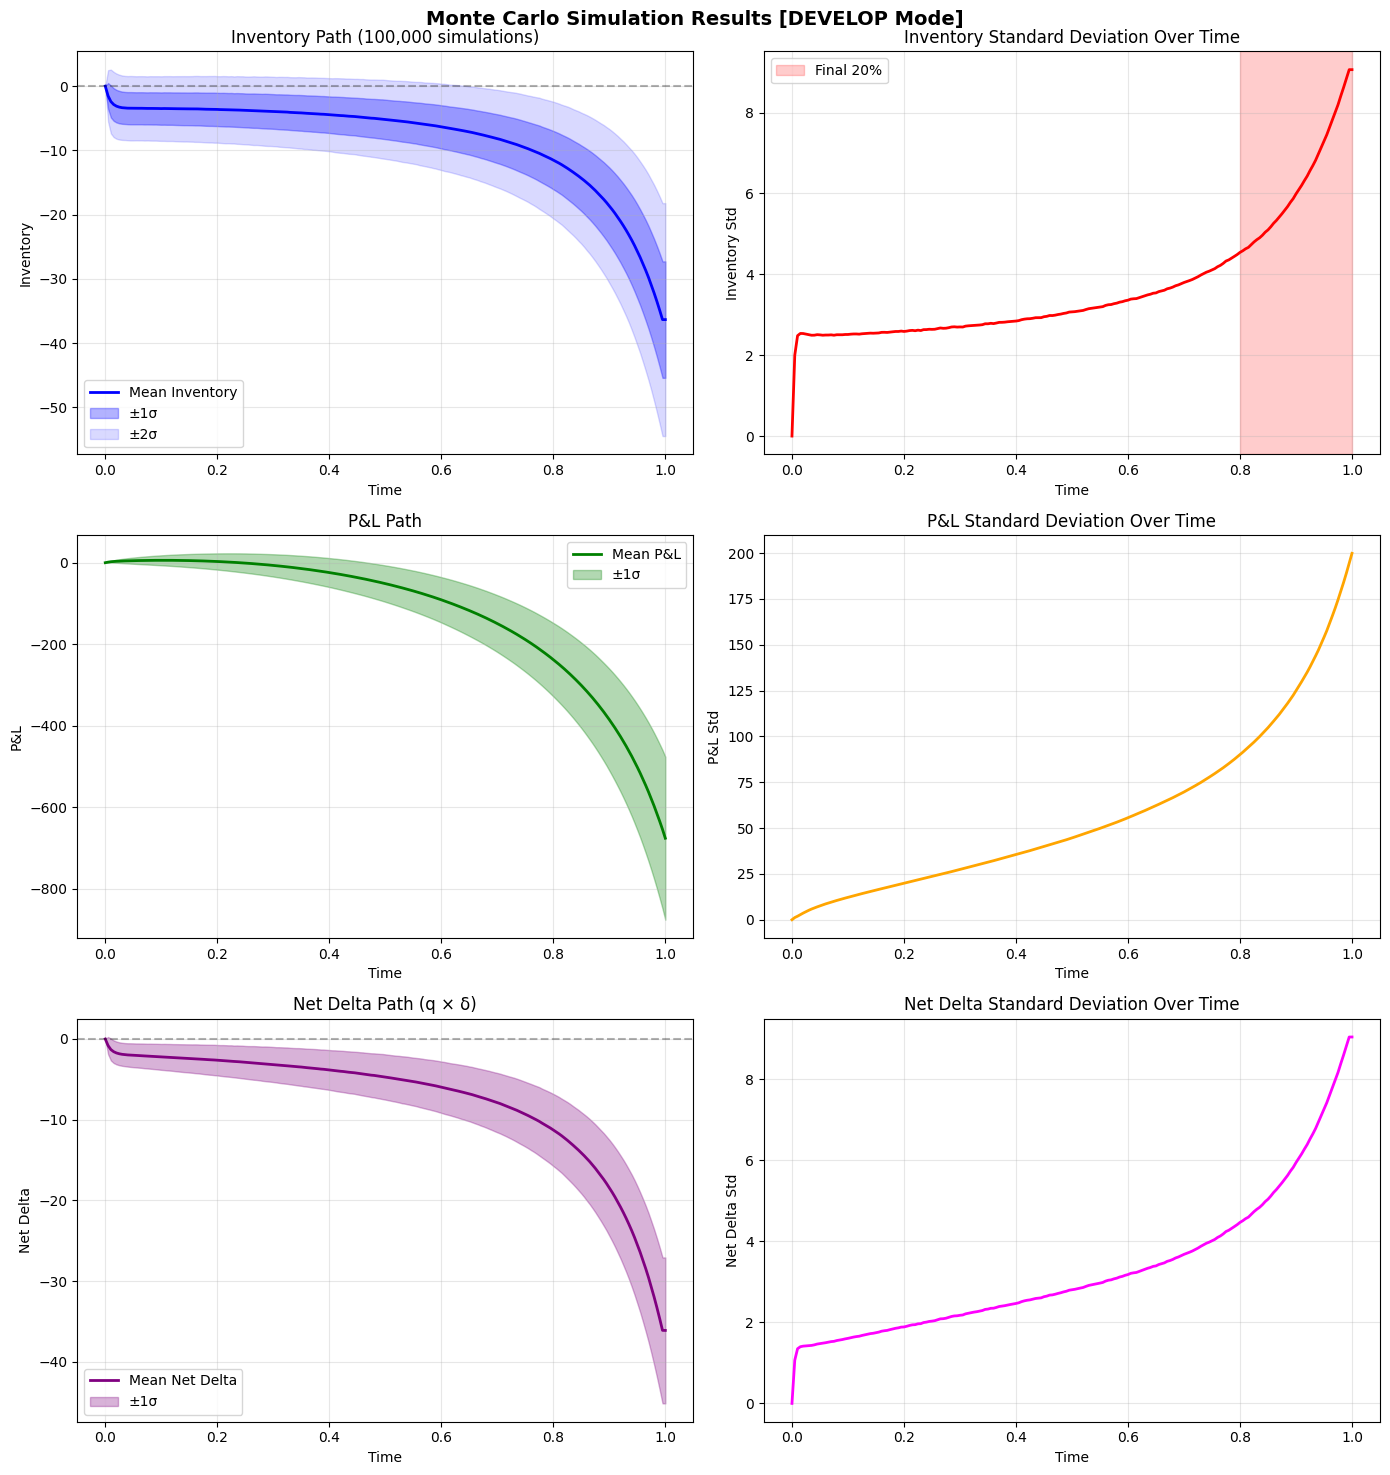

In [11]:
times = np.linspace(0, config.T, config.n_steps + 1)
mode_label = config.mode.upper()
is_develop = (config.mode == "develop")

n_rows = 3 if is_develop else 2
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 5 * n_rows))
fig.suptitle(f'Monte Carlo Simulation Results [{mode_label} Mode]', fontsize=14, fontweight='bold')

# 재고 경로
ax = axes[0, 0]
ax.plot(times, results['inv_mean'], 'b-', linewidth=2, label='Mean Inventory')
ax.fill_between(times, results['inv_mean'] - results['inv_std'],
                results['inv_mean'] + results['inv_std'], alpha=0.3, color='blue', label='±1σ')
ax.fill_between(times, results['inv_mean'] - 2*results['inv_std'],
                results['inv_mean'] + 2*results['inv_std'], alpha=0.15, color='blue', label='±2σ')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax.set_xlabel('Time')
ax.set_ylabel('Inventory')
ax.set_title(f'Inventory Path ({config.n_simulations:,} simulations)')
ax.legend()
ax.grid(True, alpha=0.3)

# 재고 표준편차
ax = axes[0, 1]
ax.plot(times, results['inv_std'], 'r-', linewidth=2)
ax.set_xlabel('Time')
ax.set_ylabel('Inventory Std')
ax.set_title('Inventory Standard Deviation Over Time')
ax.grid(True, alpha=0.3)
ax.axvspan(0.8, 1.0, alpha=0.2, color='red', label='Final 20%')
ax.legend()

# P&L 경로
ax = axes[1, 0]
ax.plot(times, results['pnl_mean'], 'g-', linewidth=2, label='Mean P&L')
ax.fill_between(times, results['pnl_mean'] - results['pnl_std'],
                results['pnl_mean'] + results['pnl_std'], alpha=0.3, color='green', label='±1σ')
ax.set_xlabel('Time')
ax.set_ylabel('P&L')
ax.set_title('P&L Path')
ax.legend()
ax.grid(True, alpha=0.3)

# P&L 표준편차
ax = axes[1, 1]
ax.plot(times, results['pnl_std'], 'orange', linewidth=2)
ax.set_xlabel('Time')
ax.set_ylabel('P&L Std')
ax.set_title('P&L Standard Deviation Over Time')
ax.grid(True, alpha=0.3)

# Net Delta (develop 모드만)
if is_develop:
    ax = axes[2, 0]
    ax.plot(times, results['nd_mean'], 'purple', linewidth=2, label='Mean Net Delta')
    ax.fill_between(times, results['nd_mean'] - results['nd_std'],
                    results['nd_mean'] + results['nd_std'], alpha=0.3, color='purple', label='±1σ')
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
    ax.set_xlabel('Time')
    ax.set_ylabel('Net Delta')
    ax.set_title('Net Delta Path (q × δ)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[2, 1]
    ax.plot(times, results['nd_std'], 'magenta', linewidth=2)
    ax.set_xlabel('Time')
    ax.set_ylabel('Net Delta Std')
    ax.set_title('Net Delta Standard Deviation Over Time')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'result/monte_carlo_paths_{config.mode}.png', dpi=150)
plt.show()

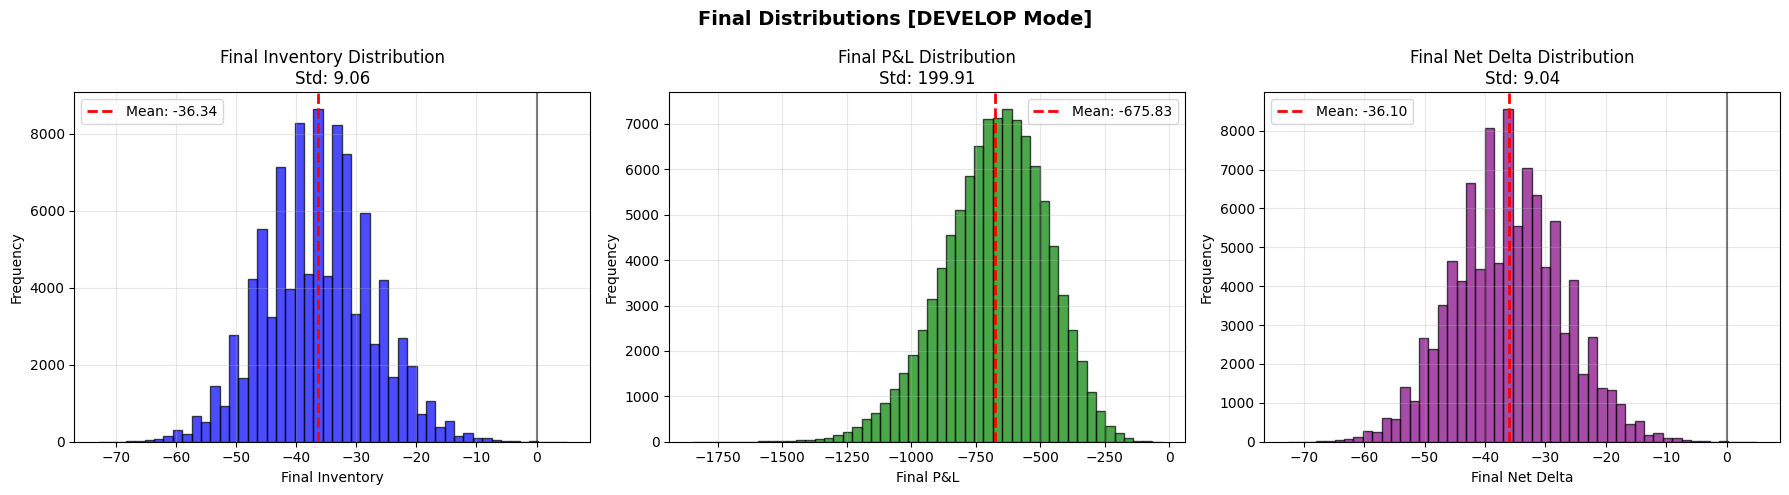

In [12]:
fig, axes = plt.subplots(1, 3 if config.mode == "develop" else 2, figsize=(18 if config.mode == "develop" else 14, 5))
fig.suptitle(f'Final Distributions [{mode_label} Mode]', fontsize=14, fontweight='bold')

ax = axes[0]
ax.hist(results['final_inventory'], bins=50, alpha=0.7, color='blue', edgecolor='black')
ax.axvline(x=np.mean(results['final_inventory']), color='red', linestyle='--', linewidth=2,
           label=f"Mean: {np.mean(results['final_inventory']):.2f}")
ax.axvline(x=0, color='black', linestyle='-', alpha=0.5)
ax.set_xlabel('Final Inventory')
ax.set_ylabel('Frequency')
ax.set_title(f'Final Inventory Distribution\nStd: {np.std(results["final_inventory"]):.2f}')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(results['final_pnl'], bins=50, alpha=0.7, color='green', edgecolor='black')
ax.axvline(x=np.mean(results['final_pnl']), color='red', linestyle='--', linewidth=2,
           label=f"Mean: {np.mean(results['final_pnl']):.2f}")
ax.set_xlabel('Final P&L')
ax.set_ylabel('Frequency')
ax.set_title(f'Final P&L Distribution\nStd: {np.std(results["final_pnl"]):.2f}')
ax.legend()
ax.grid(True, alpha=0.3)

if config.mode == "develop":
    ax = axes[2]
    ax.hist(results['final_net_delta'], bins=50, alpha=0.7, color='purple', edgecolor='black')
    ax.axvline(x=np.mean(results['final_net_delta']), color='red', linestyle='--', linewidth=2,
               label=f"Mean: {np.mean(results['final_net_delta']):.2f}")
    ax.axvline(x=0, color='black', linestyle='-', alpha=0.5)
    ax.set_xlabel('Final Net Delta')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Final Net Delta Distribution\nStd: {np.std(results["final_net_delta"]):.2f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'result/monte_carlo_distributions_{config.mode}.png', dpi=150)
plt.show()

In [ ]:
print("=" * 60)
print(f"Monte Carlo Simulation Results [{config.mode.upper()} Mode]")
print(f"({config.n_simulations:,} runs)")
print("=" * 60)
print(f"\nMode: {config.mode}")
if config.mode == "paper":
    print("  - 기본 A-S 체결 확률 (단일 호가)")
    print("  - delta <= 0: 체결 불가")
    print("  - 재고: 계약 수 q")
else:
    print("  - BSM 옵션 이론가 + Net Delta 재고")
    print("  - Multi-level 호가 (n_levels={}, tick={})".format(config.n_levels, config.tick_size))
    print("  - delta <= 0: 즉시 체결 (mid price)")
    print("  - 주가 기준 방향성 승수")
print(f"\nParameters:")
print(f"  drift: {config.drift}%, sigma(A-S): {config.sigma}, gamma: {config.gamma}")
print(f"  A: {config.A}, k: {config.k}")
if config.mode == "develop":
    print(f"  S_stock_0: {config.S_stock_0}, sigma_stock: {config.sigma_stock}")
    print(f"  BSM: K={config.K}, T_option={config.T_option}, sigma_bsm={config.sigma_bsm}")
print(f"\nFill Statistics:")
print(f"  Avg Bid Fills: {results['avg_bid_fills']:.2f}")
print(f"  Avg Ask Fills: {results['avg_ask_fills']:.2f}")
print(f"\nFinal Inventory:")
print(f"  Mean: {np.mean(results['final_inventory']):.4f}")
print(f"  Std:  {np.std(results['final_inventory']):.4f}")
print(f"  Min:  {np.min(results['final_inventory']):.0f}")
print(f"  Max:  {np.max(results['final_inventory']):.0f}")
if config.mode == "develop":
    print(f"\nFinal Net Delta:")
    print(f"  Mean: {np.mean(results['final_net_delta']):.4f}")
    print(f"  Std:  {np.std(results['final_net_delta']):.4f}")
print(f"\nFinal P&L:")
print(f"  Mean: {np.mean(results['final_pnl']):.2f}")
print(f"  Std:  {np.std(results['final_pnl']):.2f}")
print(f"  5th percentile:  {np.percentile(results['final_pnl'], 5):.2f}")
print(f"  95th percentile: {np.percentile(results['final_pnl'], 95):.2f}")
print(f"\n(T-t) Problem Indicator:")
print(f"  Inventory Std at t=0.5: {results['inv_std'][config.n_steps//2]:.4f}")
print(f"  Inventory Std at t=0.9: {results['inv_std'][int(config.n_steps*0.9)]:.4f}")
print(f"  Inventory Std at t=1.0: {results['inv_std'][-1]:.4f}")
print(f"  Ratio (t=1.0 / t=0.5): {results['inv_std'][-1] / max(results['inv_std'][config.n_steps//2], 0.0001):.2f}x")

Monte Carlo Simulation Results [DEVELOP Mode]
(100,000 runs)

Mode: develop
  - BSM 옵션 이론가 + Net Delta 재고
  - Multi-level 호가 (n_levels=3, tick=0.05)
  - delta <= 0: 즉시 체결 (mid price)
  - 주가 기준 방향성 승수

Parameters:
  drift: 15%, sigma(A-S): 2.0, gamma: 0.1
  A: 140.0, k: 1.5
  S_stock_0: 800.0, sigma_stock: 10.0
  BSM: K=800.0, T_option=0.082, sigma_bsm=0.2

Fill Statistics:
  Avg Bid Fills: 261.45
  Avg Ask Fills: 297.79

Final Inventory:
  Mean: -36.3396
  Std:  9.0629
  Min:  -73
  Max:  5

Final Net Delta:
  Mean: -36.1012
  Std:  9.0391

Final P&L:
  Mean: -675.83
  Std:  199.91
  5th percentile:  -1024.82
  95th percentile: -368.03

(T-t) Problem Indicator:
  Inventory Std at t=0.5: 3.0709
  Inventory Std at t=0.9: 5.9895
  Inventory Std at t=1.0: 9.0629
  Ratio (t=1.0 / t=0.5): 2.95x


: 